In [1]:
#Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import Sequential

import warnings
warnings.filterwarnings('ignore')

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [7]:
X_train.shape

(60000, 28, 28)

In [9]:
y_train.shape

(60000,)

In [11]:
X_test.shape

(10000, 28, 28)

In [13]:
y_test.shape

(10000,)

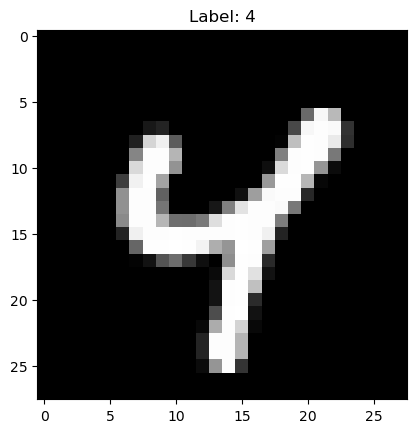

In [15]:
# Lets see visually how digit looks like

plt.imshow(X_train[1008], cmap='gray')
plt.title(f"Label: {y_train[1008]}")
plt.show()

In [17]:

X_train[1008]


array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [19]:

X_train = X_train / 255.0 
X_test=X_test / 255.0

In [21]:
X_train[1008]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [23]:

X_train_flattened = X_train.reshape(-1, 784) 
X_test_flattened = X_test.reshape(-1, 784)

In [25]:
X_train_flattened

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [29]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),  # Dense(128) -> 128 neurons active
    Dropout(0.2),                                       # 128 neurons -> ~102 active, random ~26 neurons OFF
    Dense(64, activation='relu'),                       # Outputs from remaining active neurons
    Dropout(0.2),                                       # 64 neurons -> ~51 active, random ~13 neurons OFF
    Dense(32, activation='relu'),                       # Outputs from remaining active neurons
    Dropout(0.2),                                       # 32 -> ~26 active,random ~6 neurons OFF
    Dense(10, activation='sigmoid')                     # Outputs from remaining active neurons
])

# compile model
# optimizer = 'adam' Automatically adjusts learning rate Works well in most cases

model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

# Lets train model
# epochs=5 ,Entire dataset is passed 5 times
model.fit(X_train_flattened, y_train, epochs = 5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8756 - loss: 0.4169
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9445 - loss: 0.2020
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9551 - loss: 0.1571
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9633 - loss: 0.1310
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9675 - loss: 0.1196


In [31]:
model.evaluate(X_test_flattened, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9718 - loss: 0.0958


[0.09576352685689926, 0.9718000292778015]

In [33]:
y_predict = model.predict(X_test_flattened)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [35]:
y_predict[0]

array([1.6098455e-04, 3.6291972e-02, 2.1203119e-01, 2.0440036e-01,
       1.3779167e-02, 1.8461313e-03, 3.2542208e-05, 9.9956542e-01,
       1.2873381e-03, 7.8814879e-02], dtype=float32)

In [37]:
print(np.argmax(y_predict[1456]))

6


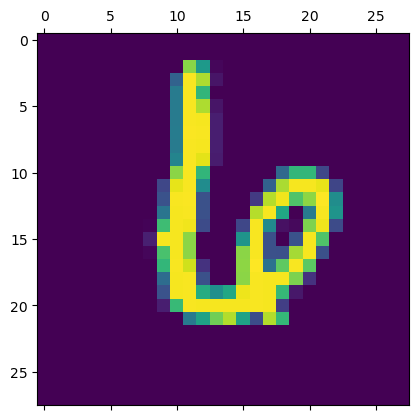

In [39]:
plt.matshow(X_test[1456])


In [45]:
model.save("digit_recognition_model.keras")